In [3]:
from dotenv import load_dotenv

load_dotenv()

True

In [4]:
from RAG.modules import logging

logging.langsmith("Model_RAG")

LangSmith 추적을 시작합니다.
[프로젝트명]
Model_RAG


In [5]:
import uuid
from langgraph.checkpoint.memory import MemorySaver

session_id = str(uuid.uuid4())
memory = MemorySaver()

In [6]:
from langchain.globals import set_verbose, set_debug

set_debug(True)
set_verbose(True)

In [7]:
from langgraph.graph import StateGraph, START, END
from RAG.types import state

In [8]:
workflow = StateGraph(state)

In [9]:
from RAG.nodes.nodes import agent, Router, grade_documents, retriever_tool, rewrite, generate, conditional_decision, conditional_retriever

C:\Users\USER\AppData\Local\Temp\ipykernel_26268\27741630.py:1: LangChainDeprecationWarning: As of langchain-core 0.3.0, LangChain uses pydantic v2 internally. The langchain_core.pydantic_v1 module was a compatibility shim for pydantic v1, and should no longer be used. Please update the code to import from Pydantic directly.

For example, replace imports like: `from langchain_core.pydantic_v1 import BaseModel`
with: `from pydantic import BaseModel`
or the v1 compatibility namespace if you are working in a code base that has not been fully upgraded to pydantic 2 yet. 	from pydantic.v1 import BaseModel

  from RAG.nodes.nodes import agent, Router, grade_documents, retriever_tool, rewrite, generate, conditional_decision, conditional_retriever


In [10]:
workflow.add_node("agent", agent)
workflow.add_node("router", Router)
workflow.add_node("retriever_tool", retriever_tool)
workflow.add_node("grade_documents", grade_documents)
workflow.add_node("rewrite", rewrite)
workflow.add_node("generate", generate)

In [11]:
workflow.add_edge(START, "router")
workflow.add_conditional_edges(
    "router",
    conditional_retriever,
    path_map={
        "retriever_tool": "retriever_tool",
        "agent": "agent",
    },
)
workflow.add_edge("agent", END)
workflow.add_edge("retriever_tool", "grade_documents")
workflow.add_conditional_edges(
    "grade_documents",
    # Assess agent decision
    conditional_decision,
    path_map={
        "generate": "generate",
        "rewrite": "rewrite",
    },
)
workflow.add_edge("generate", END)
workflow.add_edge("rewrite", "router")

In [12]:
graph = workflow.compile(checkpointer=memory)

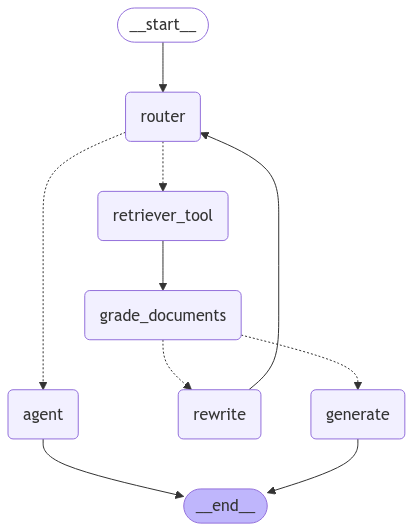

In [13]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [22]:
state: state = {
    "messages": [{"role": "user", "content": "대인 보장 범위에 대해 알려줘."}],
    "session_id": session_id,
    "metadata": {},
    "retrieved_docs": {}, 
    "answer": [],
    "previous_question": [],
    "document_grading": [],
    "insurance_grading" : [],
    "rewritten_question" : [],
    "generated_response": [], 
}

In [23]:
config = {"configurable": {"thread_id": "user_123"}} 

In [24]:
res= graph.invoke(state,  config=config)

[chain/start] [chain:LangGraph] Entering Chain run with input:
{
  "messages": [
    {
      "role": "user",
      "content": "대인 보장 범위에 대해 알려줘."
    }
  ],
  "session_id": "b1756a6f-748c-468d-bc92-cd3a1125a5d7",
  "metadata": {},
  "retrieved_docs": {},
  "answer": [],
  "previous_question": [],
  "document_grading": [],
  "insurance_grading": [],
  "rewritten_question": [],
  "generated_response": []
}
[chain/start] [chain:LangGraph > chain:__start__] Entering Chain run with input:
{
  "messages": [
    {
      "role": "user",
      "content": "대인 보장 범위에 대해 알려줘."
    }
  ],
  "session_id": "b1756a6f-748c-468d-bc92-cd3a1125a5d7",
  "metadata": {},
  "retrieved_docs": {},
  "answer": [],
  "previous_question": [],
  "document_grading": [],
  "insurance_grading": [],
  "rewritten_question": [],
  "generated_response": []
}
[chain/start] [chain:LangGraph > chain:__start__ > chain:ChannelWrite<...>] Entering Chain run with input:
{
  "messages": [
    {
      "role": "user",
      "conten

In [17]:
print(res['messages'][-1])

대인 보장 범위는 다음과 같습니다:

- **운전자용 교통상해후유장해**: 교통사고로 인한 장해 상태가 3~100%에 해당할 경우, 가입금액에 지급률을 곱하여 지급.
- **비운전자용 교통상해후유장해**: 비운전 중 교통사고로 인한 장해 상태가 3~100%에 해당할 경우, 가입금액에 지급률을 곱하여 지급.
- **80% 이상 후유장해 재활자금**: 교통사고로 장해 지급률이 80% 이상일 경우, 매월 가입금액의 60배를 5년간 지급.
- **교통상해 입원일당**: 교통사고로 입원 치료를 받은 경우, 입원 1일당 가입금액 지급.
- **외상성 척추 손상 수술비**: 상해로 외상성 척추 손상을 입고 수술을 받은 경우, 가입금액 지급.
- **상해 응급실 내원비**: 응급환자에 해당하여 응급실에 내원한 경우, 정해진 금액 지급.

이 외에도 다양한 보장 항목이 있으며, 각 항목에 따라 지급 금액과 조건이 다를 수 있습니다.


In [18]:
# inputs = {
#     "messages": [
#         ("user", "대인 부분 약관과 보장 범위에 대해 알려줘."),
#     ]
# }

In [19]:
# # 스트림 실행 및 출력 처리
# from pprint import pprint

# config = {"configurable": {"thread_id": "user_123"}}  # 필요한 설정 추가

# for output in graph.stream(state, config=config):
#     for node, result in output.items():
#         print(f"\n{'-' * 10} Output from node '{node}' {'-' * 10}\n")
#         if "messages" in result:
#             for message in result["messages"]:
#                 if isinstance(message, dict) and "content" in message:
#                     print(f"**Message Content**: {message['content']}\n")
#         else:
#             pprint(result, indent=2, width=80, depth=None)
#         print("\n" + "-" * 30 + "\n")

[chain/start] [chain:LangGraph] Entering Chain run with input:
{
  "messages": [
    {
      "role": "user",
      "content": "대인 보장 범위에 대해 알려줘."
    }
  ],
  "session_id": "",
  "metadata": {},
  "retrieved_docs": {},
  "answer": [],
  "previous_question": [
    [
      {
        "role": "user",
        "content": "대인 보장 범위에 대해 알려줘."
      }
    ]
  ],
  "document_grading": [],
  "insurance_grading": [],
  "rewritten_question": [],
  "generated_response": []
}
[chain/start] [chain:LangGraph > chain:__start__] Entering Chain run with input:
{
  "messages": [
    {
      "role": "user",
      "content": "대인 보장 범위에 대해 알려줘."
    }
  ],
  "session_id": "",
  "metadata": {},
  "retrieved_docs": {},
  "answer": [],
  "previous_question": [
    [
      {
        "role": "user",
        "content": "대인 보장 범위에 대해 알려줘."
      }
    ]
  ],
  "document_grading": [],
  "insurance_grading": [],
  "rewritten_question": [],
  "generated_response": []
}
[chain/start] [chain:LangGraph > chain:__start__ >

In [20]:
from modules.messages import display_message_tree

In [26]:
display_message_tree(res)

[messages]:
    messages[0]:
        messages[0]: 대인 보장 범위는 다음과 같습니다:

- **운전자용 교통상해후유장해**: 교통사고로 인한 장해 상태가 3~100%일 경우, 가입금액에 지급률을 곱하여 지급.
- **비운전자용 교통상해후유장해**: 비운전 중 교통사고로 인한 장해 상태가 3~100%일 경우, 가입금액에 지급률을 곱하여 지급.
- **80% 이상 후유장해 재활자금**: 교통사고로 장해 상태가 80% 이상일 경우, 매월 가입금액의 60배를 5년간 지급.
- **교통상해 입원일당**: 교통사고로 입원 치료를 받은 경우, 입원 1일당 가입금액 지급.
- **외상성 척추 손상 수술비**: 상해로 인한 외상성 척추 손상 수술 시 가입금액 지급.
- **상해 응급실 내원비**: 응급환자에 해당하는 경우, 응급실 내원비 지급.

이 외에도 다양한 보장 항목이 있으며, 각 항목에 따라 지급 금액과 조건이 다를 수 있습니다.
[session_id]:
    session_id: b1756a6f-748c-468d-bc92-cd3a1125a5d7
[metadata]:
[retrieved_docs]:
    retrieved_docs[0]:
        retrieved_docs[0]: page_content='Ⅱ 20만원, 골절수술비Ⅱ 20만원, 5대골절진단비 20만원, 5대골절수술비 20만원, 신깁스치료비 10만
원, 깁스치료비 10만원, 특정단순창상봉합술치료비(급여,연간3회한) 3만원, 외상성척추손상수술비 20
만원, 상해응급실내원비(응급) 2만원, 운전자용 교통상해후유장해(3~100%) 3천만원, 운전자용 교통상
해80%이상후유장해재활자금 1백만원
기준
보험가격지수(%)
40세, 20년만기 전기납
남자
91.2
여자
91.2
4. 보험가격지수
보험가격지수란?
해당상품의 보험료총액(보험금 지급을 위한 보험료 및 보험회사의 사업경비 등을 위한 보험료)을 참조순
보험료 총액*과 평균사업비총액**을 합한 금액으로 나눈 비율을 

In [27]:
mu = /tailorlink/milvus/MILVUS_URI

SyntaxError: invalid syntax (2864206497.py, line 1)

SyntaxError: invalid syntax (2002231866.py, line 1)